# Streaming, Prompt Chaining, and Parallelization in langGraph

In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.X_AI_GROK_4_FAST
# model_str2_remote: str = RemoteModel.QWEN3_30B_A3B
model_str_local: str = LocalModel.LLAMA3_1_8B

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)


local_llm = ChatOpenAI(
    api_key=settings.LMSTUDIO_API_KEY.get_secret_value(),
    base_url=settings.LMSTUDIO_URL,
    temperature=0.0,
    model=model_str_local,
)

# Test the LLMs
response = remote_llm.invoke("Tell me a very short joke.")
response.pretty_print()

================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


# Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

[![image.png](https://i.postimg.cc/qqqR58h7/image.png)](https://postimg.cc/RJr43JTr)

In [5]:
from typing import Annotated, TypedDict

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph.message import add_messages

In [6]:
from IPython.display import Image, Markdown, display
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

### Create A Simple Graph

In [7]:
class State(TypedDict):
    messages: Annotated[list[Any], add_messages]


async def call_llm(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    response = await remote_llm.ainvoke(input=state["messages"])

    return {"messages": [response]}

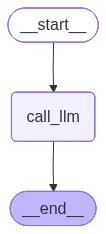

In [8]:
builder = StateGraph(State)

# Nodes
builder.add_node("call_llm", call_llm)

# Edges
builder.add_edge(START, "call_llm")
builder.add_edge("call_llm", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

### Normal Invocation

In [9]:
config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"messages": "Tell me a very short joke."},
    config=config,
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Tell me a very short joke.
================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


### With Streaming

In [10]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

response = await graph.ainvoke(
    {"messages": "Tell me a very short joke."},
    config=config,
    stream_mode="updates",
)

for chunk in response:
    console.print(chunk)

{
    'call_llm': {
        'messages': [
            AIMessage(
                content='Why did the bicycle fall over? It was two-tired!',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 165,
                        'prompt_tokens': 190,
                        'total_tokens': 355,
                        'completion_tokens_details': {
                            'accepted_prediction_tokens': None,
                            'audio_tokens': None,
                            'reasoning_tokens': 152,
                            'rejected_prediction_tokens': None
                        },
                        'prompt_tokens_details': None
                    },
                    'model_name': 'x-ai/grok-4-fast',
                    'system_fingerprint': None,
                    'id': 'gen-1761062505-hUZ2MM5WoojgqNQ5OLZj',
                    'service_tier': None,
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='run--fe2aeff9-27a8-4f10-866a-97908d9b2699-0',
                usage_metadata={
                    'input_tokens': 190,
                    'output_tokens': 165,
                    'total_tokens': 355,
                    'input_token_details': {},
                    'output_token_details': {'reasoning': 152}
                }
            )
        ]
    }
}

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [11]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

async for event in graph.astream_events(
    {"messages": "Tell me a very short joke."}, config=config
):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Tell me a very short joke.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '20282080-bd0f-4591-b52b-75b7f5341463', 'metadata': {'thread_id': '1'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Tell me a very short joke.', additional_kwargs={}, response_metadata={}, id='eb91260c-688e-48aa-95f6-51c2b89fb7f2'), AIMessage(content="Why don't scientists trust atoms? Because they make up everything!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 163, 'total_tokens': 235, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 60, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_name': 'x-ai/grok-4-fast', 'system_fingerprint': None, 'id': 'gen-1761062504-TIh06At39LAIzM751Ahh', 'service_tier': None, 'finish_reason': 'stop', 'logprobs': No

# Prompt Chaining

- Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. 

- Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. 

- This approach can improve accuracy, coherence, and control when working with large language models.

- LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. 

- It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.

<br>

### How Prompt Chaining Works with LangGraph

1. **Define the Task**: Start by breaking down the problem into smaller sub-tasks. 
  - For example, if you want to generate a detailed report, you might split it into steps like `"gather data"`, `"analyze data"`, and `"write summary"`.

2. **Create Nodes**: Each sub-task becomes a node in the LangGraph structure. 
  - A node could be a prompt that instructs the model to perform a specific action, such as `"List key facts about X"` or `"Summarize the following text."`

3. **Establish Edges**: Edges define the sequence and dependencies between nodes. 
  - For instance, the output of the `"gather data"` node flows into the `"analyze data"` node, ensuring the model has the necessary context to proceed.

4. **Execute the Graph**: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. **Iterate if Needed**: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

### Example of Prompt Chaining with LangGraph

- Create a LangGraph that chains prompts to generate a story based on user input.

In [12]:
from pydantic import BaseModel, Field

type PydanticModel = type[BaseModel]
min_score: int = 1
max_score: int = 10


class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    score_info: dict[str, Any]
    runs: int
    final_story: str


class StoryScore(BaseModel):
    score: int = Field(
        ...,
        ge=min_score,
        le=max_score,
        description=f"Score from {min_score} (poor) to {max_score} (excellent)",
    )
    reason: str = Field(..., description="Reason for the score")


# ==================================================================
# ============================ PROMPTS =============================
# ==================================================================
create_story_prompt: str = """
<INSTR>
You're a storyteller. Create a short story of about 100 words about this 
<TOPIC>{topic}</TOPIC>
</INSTR> 
"""

create_improved_story_prompt: str = """
<INSTR>
You're a storyteller. Create an improved cohesive story of about 100 words using this 
<TOPIC>{topic}</TOPIC> <IMPROVEMENT_REASON>{reason}</IMPROVEMENT_REASON> 
and this initial story: <STORY>{story}</STORY>
Do NOT diverge from the topic.
</INSTR> 
"""

story_validator_prompt: str = """
<INSTR>
You are a strict story validator. Rate the story from {min_score} to {max_score}.

Evaluate <STORY>{story}</STORY> based on <TOPIC>{topic}</TOPIC>:

1. **Relevance (30%)** — Story directly addresses the topic
2. **Structure (20%)** — Clear beginning, middle, end with logical flow
3. **Clarity & Grammar (20%)** — No errors, precise language
4. **Creativity (15%)** — Original ideas, avoids clichés and generic phrases
5. **Engagement (15%)** — Compelling through vivid details or emotional resonance

Scoring rules:
- {max_score}: Flawless across ALL criteria (extremely rare)
- Deduct 1-2 points for each: cliché, grammar error, weak relevance, structural gap
- Any cliché or generic phrase caps creativity at 8/10 maximum
- Be harsh: average stories score 6-7, good stories 8, only exceptional stories 9+
- The final score should be closer to the LOWEST sub-score among the criteria

</INSTR>
"""

In [13]:
# ==================================================================
# ============================= LLMS ===============================
# ==================================================================
creative_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=1.25,
    model=RemoteModel.GEMINI_2_0_FLASH_001,
)
rigid_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# ==================================================================
# ============================= NODES ==============================
# ==================================================================
async def create_story(state: State) -> dict[str, Any]:
    prompt: str = create_story_prompt.format(topic=state["topic"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story": response.content}


async def rate_story(state: State) -> dict[str, Any]:
    prompt: str = story_validator_prompt.format(
        topic=state["topic"],
        min_score=min_score,
        max_score=max_score,
        story=state["story"],
    )
    llm_with_structured_output = rigid_llm.with_structured_output(StoryScore)
    response: PydanticModel = await llm_with_structured_output.ainvoke(input=prompt)
    return {
        "story": state["story"],
        "improved_story": state.get("improved_story", ""),
        "score_info": response.model_dump(),
    }


async def create_improved_story(state: State) -> dict[str, Any]:
    runs: int = state.get("runs", 0)
    state["runs"] = runs + 1
    prompt: str = create_improved_story_prompt.format(
        topic=state["topic"], reason=state["score_info"]["reason"], story=state["story"]
    )
    response = await creative_llm.ainvoke(input=prompt)
    return {
        "story": state["story"],
        "improved_story": response.content,
        "runs": state["runs"],
    }


def publish_story(state: State) -> dict[str, Any]:
    return {
        "final_story": (
            state["improved_story"] if state["improved_story"] else state["story"]
        )
    }


# Conditional node
def router(state: State) -> Literal["pass", "fail"]:
    score: int = state["score_info"].get("score", 1)
    runs: int = state.get("runs", 0)

    if score > 8 or runs >= 2:
        return "pass"
    return "fail"

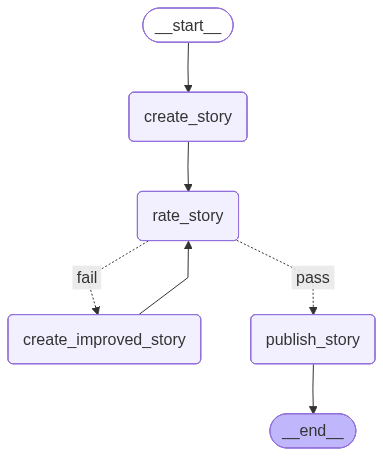

In [14]:
builder = StateGraph(State)

# Nodes
builder.add_node("create_story", create_story)
builder.add_node("rate_story", rate_story)
builder.add_node("create_improved_story", create_improved_story)
builder.add_node("publish_story", publish_story)


# Edges
builder.add_edge(START, "create_story")
builder.add_edge("create_story", "rate_story")
builder.add_conditional_edges(
    "rate_story",
    router,
    {
        "pass": "publish_story",
        "fail": "create_improved_story",
    },
)
builder.add_edge("create_improved_story", "rate_story")
builder.add_edge("publish_story", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [15]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"topic": "Tyrion Lannister's role in Game of Thrones"},
    config=config,
)

console.print(response)

{
    'topic': "Tyrion Lannister's role in Game of Thrones",
    'story': "Tyrion Lannister, the imp with the sharpest mind in Westeros, danced a dangerous dance. Initially 
sidelined for his dwarfism, he rose to Hand of the King, defending King's Landing with fire and wit. His 
brilliance, however, was often overshadowed by his family's ruthless reputation. Betrayed and unjustly accused, 
Tyrion delivered a blistering speech, disowning his name and murdering his father. \n\nHe fled across the Narrow 
Sea, finding purpose in Daenerys Targaryen's ambition. As her advisor, he tempered her fire with pragmatism, 
guiding her towards the Iron Throne. But even with the best intentions, he couldn't prevent the blaze, ultimately 
advocating for a different kind of ruler, one chosen by the people, not blood.\n",
    'improved_story': "Tyrion Lannister, underestimated for his stature but armed with cunning, navigated a 
treacherous court. He ascended to Hand, his strategic brilliance repelling Stannis's siege, a victory born of 
intellect. Yet, blood ties proved a cage, leading to accusations and Cersei's venom. Wrongfully condemned, he 
unleashed a torrent of truth, silencing his father before escaping to Essos.\n\nA new dawn beckoned in Daenerys 
Targaryen, a queen he hoped to mold. He became her anchor, grounding her fiery spirit with calculated counsel. 
Though he steered her towards Westeros, the inferno consumed his ideals. In the ashes, he envisioned a council, not
a dynasty, a leader chosen, not born.\n",
    'score_info': {
        'score': 8,
        'reason': "Relevance (10/10): Directly and comprehensively addresses Tyrion Lannister's arc in Game of 
Thrones, from his rise as Hand to advising Daenerys. Structure (9/10): Clear progression with beginning (rise and 
defense), middle (betrayal and flight), and end (advisory role), though concise summary format limits depth. 
Clarity & Grammar (10/10): Precise, error-free language with evocative phrasing. Creativity (7/10): Some original 
metaphors like 'danced a dangerous dance' and 'tempered her fire,' but relies on familiar tropes (e.g., 'sharpest 
mind,' 'blistering speech'), capping score per rules. Engagement (8/10): Compelling emotional resonance in betrayal
and redemption themes. Final score leans toward lowest sub-score (creativity) for a solid but not exceptional 
retelling."
    },
    'runs': 2,
    'final_story': "Tyrion Lannister, underestimated for his stature but armed with cunning, navigated a 
treacherous court. He ascended to Hand, his strategic brilliance repelling Stannis's siege, a victory born of 
intellect. Yet, blood ties proved a cage, leading to accusations and Cersei's venom. Wrongfully condemned, he 
unleashed a torrent of truth, silencing his father before escaping to Essos.\n\nA new dawn beckoned in Daenerys 
Targaryen, a queen he hoped to mold. He became her anchor, grounding her fiery spirit with calculated counsel. 
Though he steered her towards Westeros, the inferno consumed his ideals. In the ashes, he envisioned a council, not
a dynasty, a leader chosen, not born.\n"
}

In [16]:
Markdown(response["final_story"])

Tyrion Lannister, underestimated for his stature but armed with cunning, navigated a treacherous court. He ascended to Hand, his strategic brilliance repelling Stannis's siege, a victory born of intellect. Yet, blood ties proved a cage, leading to accusations and Cersei's venom. Wrongfully condemned, he unleashed a torrent of truth, silencing his father before escaping to Essos.

A new dawn beckoned in Daenerys Targaryen, a queen he hoped to mold. He became her anchor, grounding her fiery spirit with calculated counsel. Though he steered her towards Westeros, the inferno consumed his ideals. In the ashes, he envisioned a council, not a dynasty, a leader chosen, not born.


# Parallelization

<br>

- In LangGraph, nodes typically execute in a sequence defined by edges, but when tasks don’t depend on each other’s outputs, you can run them in parallel. 

- This is achieved by:
  - Defining multiple nodes that can operate independently.

  - Connecting them to a common starting point (e.g., START or another node).

  - Merging their outputs into a downstream node if needed.

- LangGraph handles this implicitly when nodes are independent and can leverage multi-threading or asynchronous execution under the hood, depending on the runtime environment (e.g., Python’s asyncio or a multi-threaded executor).

<br>

<img src="https://i.postimg.cc/y8zhN4nX/image.png" width="400" alt="image">

### Parallelization Example

In [17]:
class State(TypedDict):
    topic_1: str
    topic_2: str
    topic_3: str

    story_1: str
    story_2: str
    story_3: str

    aggregated_story: str


story_prompt: str = """
<INSTR>You're a creative story teller. Write a short story of about 3 sentences using this 
<TOPIC>{topic}</TOPIC> 
</INSTR>
"""

story_aggregator_prompt: str = """
<INSTR>
You are a **skilled and disciplined story aggregator**. Your task is to merge and refine multiple stories into one cohesive narrative while preserving key ideas from each source.

Use the context below to craft the final output:
<CONTEXT>
    <STORY>{story_1}</STORY>
    <STORY>{story_2}</STORY>
    <STORY>{story_3}</STORY>
</CONTEXT>

<OUTPUT_FORMAT>
- Then, write a **final unified story** that merges the essence of all three into a **single, cohesive narrative of exactly three sentences**.
- Maintain clear transitions and logical flow between ideas.
- Ensure the final story reads smoothly, with consistent tone, tense, and perspective.
</OUTPUT_FORMAT>
</INSTR>
"""

In [18]:
# ==================================================================
# ============================= LLMS ===============================
# ==================================================================
creative_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.5,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# ==================================================================
# ============================= NODES ==============================
# ==================================================================
async def create_story_1(state: State) -> dict[str, Any]:
    prompt: str = story_prompt.format(topic=state["topic_1"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story_1": response.content}


async def create_story_2(state: State) -> dict[str, Any]:
    prompt: str = story_prompt.format(topic=state["topic_2"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story_2": response.content}


async def create_story_3(state: State) -> dict[str, Any]:
    prompt: str = story_prompt.format(topic=state["topic_3"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story_3": response.content}


async def aggregate_stories(state: State) -> dict[str, Any]:
    prompt: str = story_aggregator_prompt.format(
        story_1=state["story_1"],
        story_2=state["story_2"],
        story_3=state["story_3"],
    )
    response = await creative_llm.ainvoke(input=prompt)
    return {"aggregated_story": response.content}

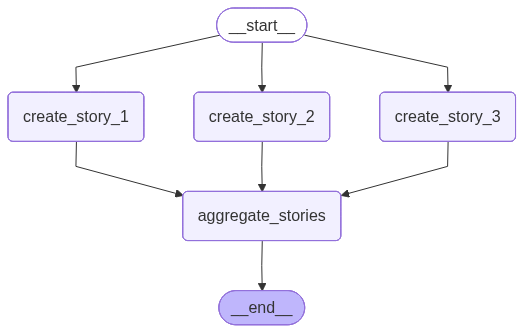

In [19]:
builder = StateGraph(State)

# Nodes
builder.add_node("create_story_1", create_story_1)
builder.add_node("create_story_2", create_story_2)
builder.add_node("create_story_3", create_story_3)
builder.add_node("aggregate_stories", aggregate_stories)


# Edges
builder.add_edge(START, "create_story_1")
builder.add_edge(START, "create_story_2")
builder.add_edge(START, "create_story_3")

builder.add_edge("create_story_1", "aggregate_stories")
builder.add_edge("create_story_2", "aggregate_stories")
builder.add_edge("create_story_3", "aggregate_stories")

builder.add_edge("aggregate_stories", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [20]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"topic_1": "Messi", "topic_2": "Cristiano Ronaldo", "topic_3": "Neymar Jr"},
    config=config,
)

console.print(response)

{
    'topic_1': 'Messi',
    'topic_2': 'Cristiano Ronaldo',
    'topic_3': 'Neymar Jr',
    'story_1': 'In the sun-drenched streets of Buenos Aires, young Leo Messi chased a worn-out ball through dusty 
alleys, his tiny frame belying the fire in his eyes that dreamed of glory. As scouts whispered his name and trials 
tested his unyielding spirit, he rose like a phoenix, turning skepticism into awe with every dazzling dribble on 
the pitch. Today, the world hails him as the maestro of the game, a legend whose magic reminds us that true 
greatness blooms from the heart of perseverance.',
    'story_2': "In the bustling streets of Madeira, young Cristiano Ronaldo chased a worn-out ball through narrow 
alleys, his dreams as vast as the ocean beyond the cliffs. As he grew, the world became his pitch, where every goal
scored against giants like Real Madrid and Manchester United etched his name into soccer's hall of fame, turning 
doubters into devotees. Even in the twilight of his career, Ronaldo's unyielding spirit reminded everyone that true
legends are forged not just by talent, but by the fire of relentless pursuit.",
    'story_3': "In the bustling streets of Rio de Janeiro, young Neymar Jr dribbled a worn-out soccer ball past 
imaginary defenders, his feet dancing like flames on the pavement. As the sun dipped below the horizon, he dreamed 
of stadiums filled with roaring crowds, vowing to turn his flair into legend. Years later, on the grand stage of 
the World Cup, Neymar's dazzling goal silenced the doubters and ignited the hearts of millions, proving that 
passion could conquer any field.",
    'aggregated_story': "In the vibrant streets of Buenos Aires, Madeira, and Rio de Janeiro, young Leo Messi, 
Cristiano Ronaldo, and Neymar Jr. chased worn-out balls through dusty alleys and narrow paths, their small frames 
fueled by dreams as boundless as the horizons they gazed upon—glory on sunlit pitches and roaring stadiums. As 
scouts took notice and trials forged their unyielding spirits, they rose like phoenixes, dazzling the world with 
intricate dribbles, goals against giants like Real Madrid and Manchester United, and World Cup moments that 
silenced doubters and etched their names into soccer's hall of fame. Today, these maestros remind us that true 
legends bloom from perseverance, relentless pursuit, and the fiery passion that turns flair into eternal magic on 
the field."
}

In [21]:
Markdown(response["aggregated_story"])

In the vibrant streets of Buenos Aires, Madeira, and Rio de Janeiro, young Leo Messi, Cristiano Ronaldo, and Neymar Jr. chased worn-out balls through dusty alleys and narrow paths, their small frames fueled by dreams as boundless as the horizons they gazed upon—glory on sunlit pitches and roaring stadiums. As scouts took notice and trials forged their unyielding spirits, they rose like phoenixes, dazzling the world with intricate dribbles, goals against giants like Real Madrid and Manchester United, and World Cup moments that silenced doubters and etched their names into soccer's hall of fame. Today, these maestros remind us that true legends bloom from perseverance, relentless pursuit, and the fiery passion that turns flair into eternal magic on the field.

### Key Benefits of Parallelization

- Speed: Reduces total execution time by running tasks concurrently.

- Scalability: Handles larger workflows efficiently.

- Modularity: Keeps the graph structure clean and reusable.

#### Key Takeaways
- When to Parallelize: Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

- Merging: Downstream nodes can aggregate parallel results.

- LangGraph Support: The framework naturally supports this by waiting for all required inputs before proceeding.

